## TS2: Modelizando un ADC



En esta tarea semanal retomamos la consigna de la tarea anterior, donde simulamos el bloque de cuantización de un ADC de B bits en un rango de  ±VF
 Volts. Ahora vamos a completar la simulación del ADC incluyendo la capacidad de muestrear a fs Hertz.

Para ello se simulará el comportamiento del dispositivo al digitalizar una senoidal contaminada con un nivel predeterminado de ruido. Comenzaremos describiendo los parámetros a ajustar de la senoidal:

frecuencia f0
 arbitraria, por ejemplo f0=fS/N=Δf
 
energía normalizada, es decir energía (o varianza) unitaria
Con respecto a los parámetros de la secuencia de ruido, diremos que:

será de carácter aditivo, es decir la señal que entra al ADC será sR=s+n
. Siendo n
 la secuencia que simula la interferencia, y s
 la senoidal descrita anteriormente.
La potencia del ruido será Pn=kn.Pq
 W siendo el factor k una escala para la potencia del ruido de cuantización Pq=q212
.
finalmente, n
 será incorrelado y Gaussiano.
El ADC que deseamos simular trabajará a una frecuencia de muestreo fS=1000
 Hz y tendrá un rango analógico de ±VF=2
 Volts.


Se pide:

a) Generar el siguiente resultado producto de la experimentación. B = 4 bits, kn=1

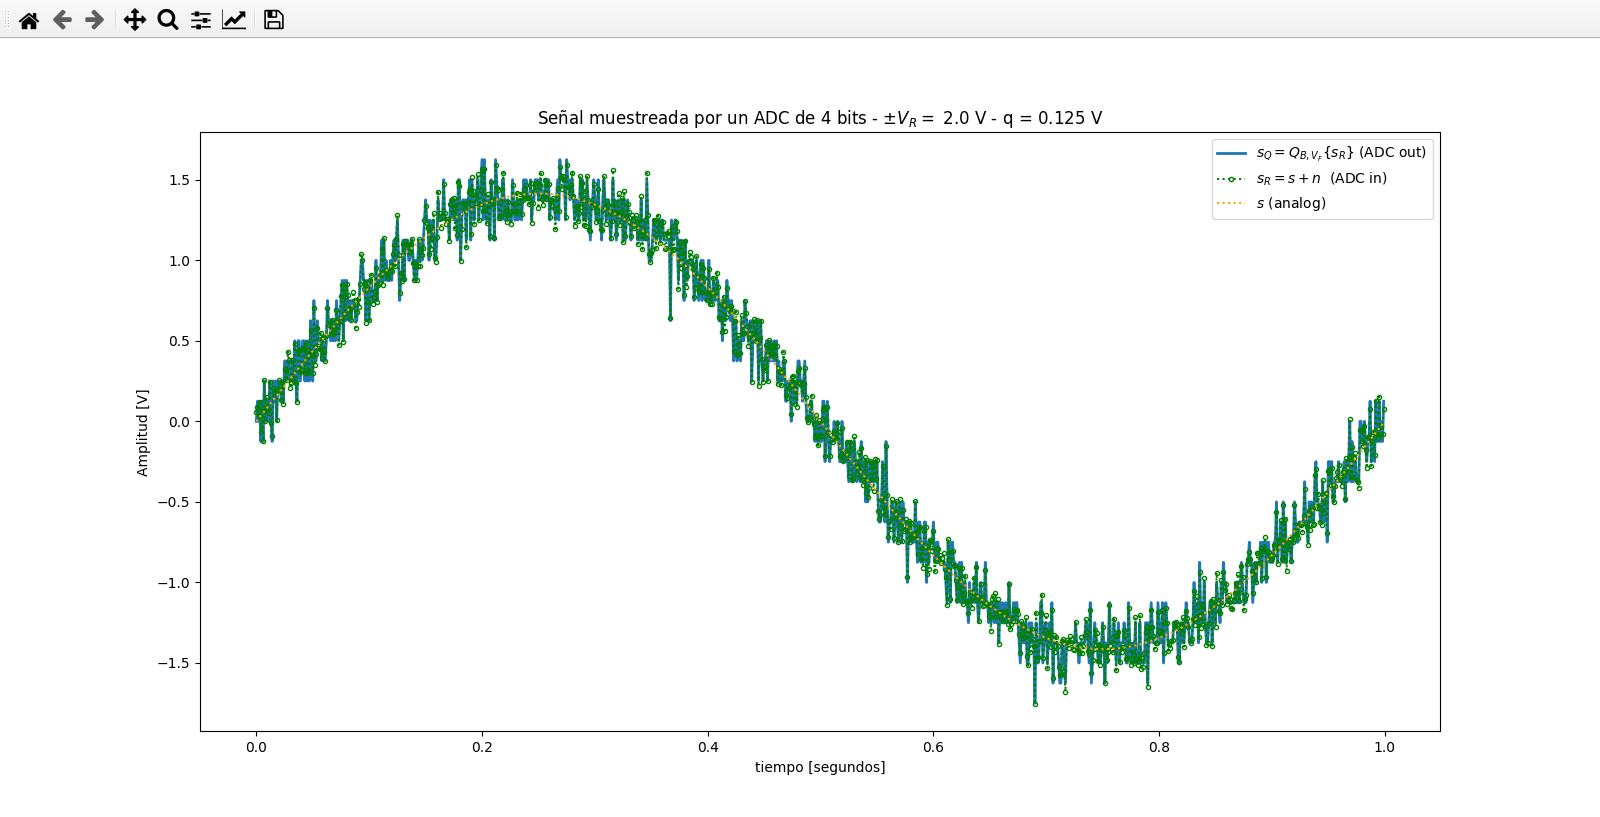

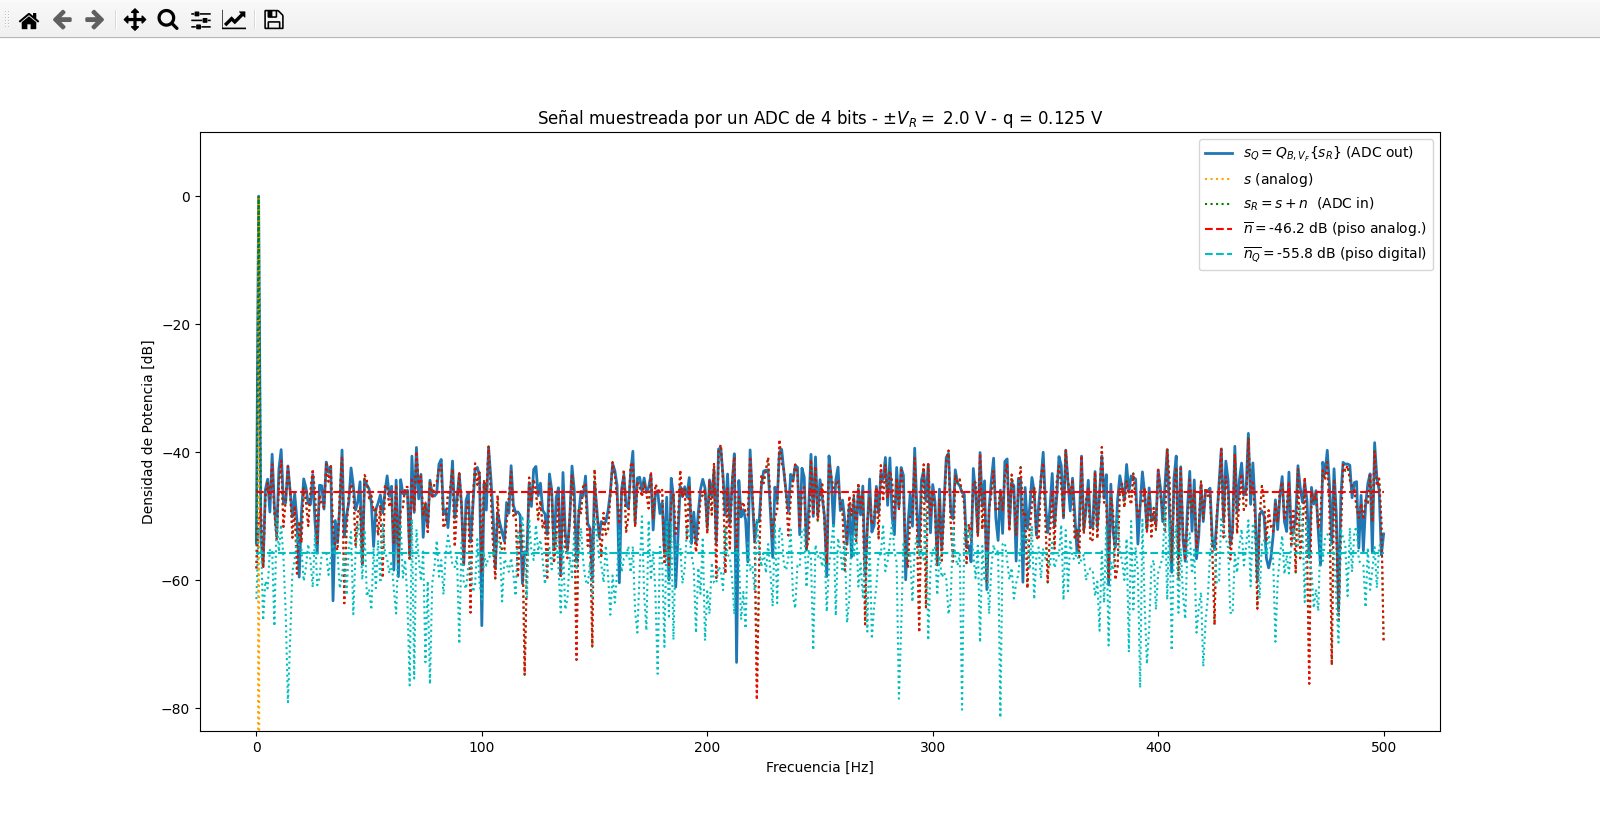

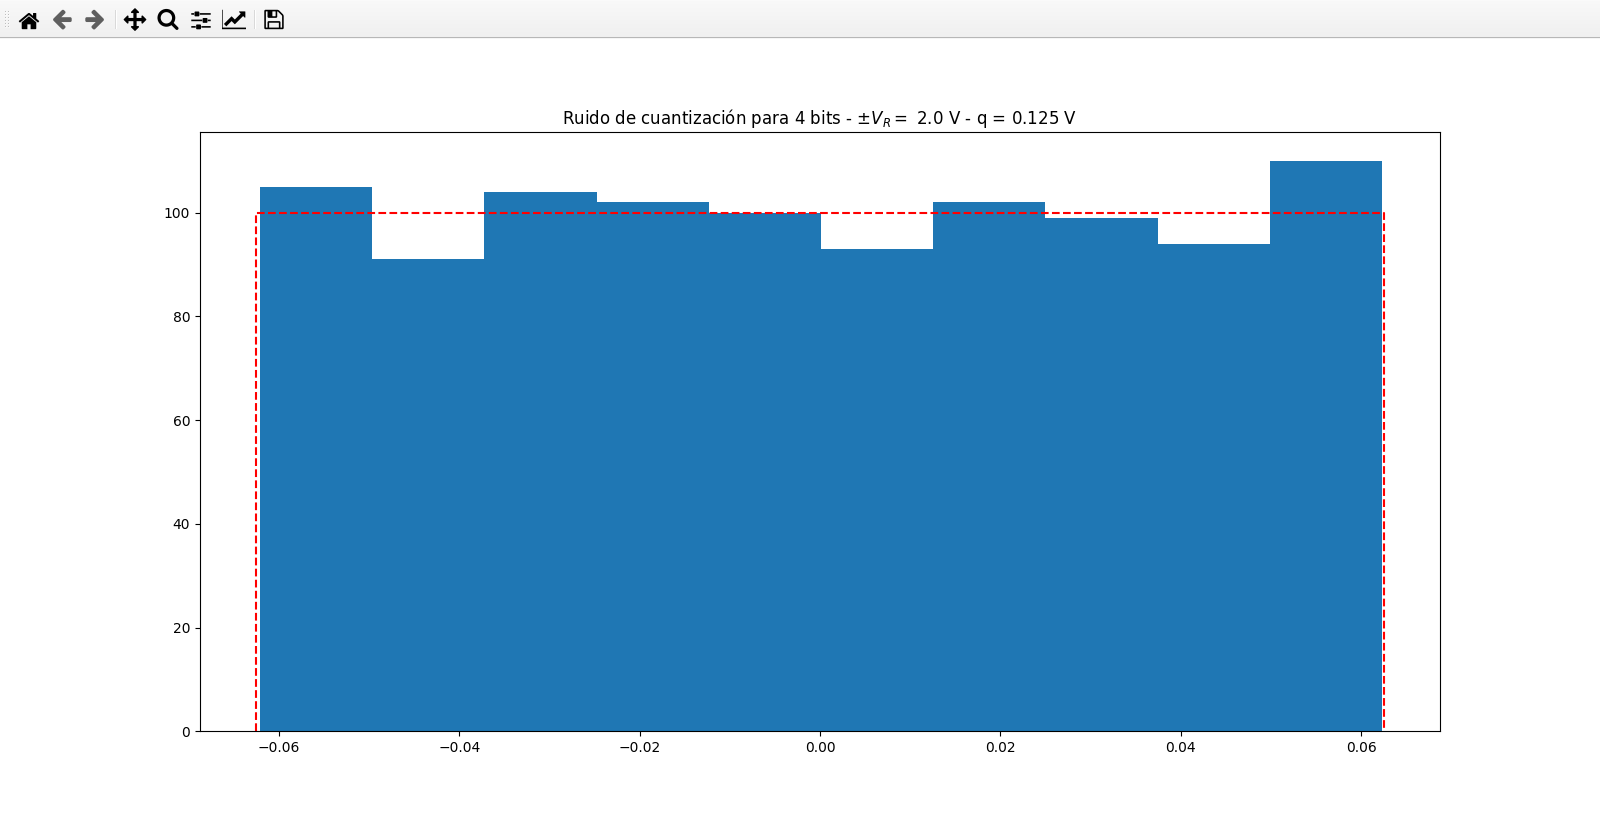

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig

# params
fs = 1000.0
N = 1000
f0 = fs / N 
V_F = 2.0 
B = 4 
kn = 1.0 

# paso de cuantizacion q
q = (2 * V_F) / (2**B)  # me da 0.25
#q=0.125 usado en los graficos de ej

# potencia teorica del ruido de cuantizacion y ruido analogico
Pq = (q**2) / 12
Pn = kn * Pq
sigma_n = np.sqrt(Pn) # Desvio ruido Gaussiano

# senales

np.random.seed(0)   # reproducibilidad

t = np.arange(N) / fs

# senal analogica
s = np.sqrt(2) * np.sin(2 * np.pi * f0 * t)

# ruido Gaussiano incorrelado n
n = np.random.normal(0, sigma_n, N)

# senal ruidosa que ingresa al ADC
s_R = s + n

# cuantizacion
s_Q = np.round(s_R / q) * q

# saturacion
s_Q = np.clip(s_Q, -V_F, V_F - q)

# ruido de cuantizacion resultante
e_q = s_Q - s_R

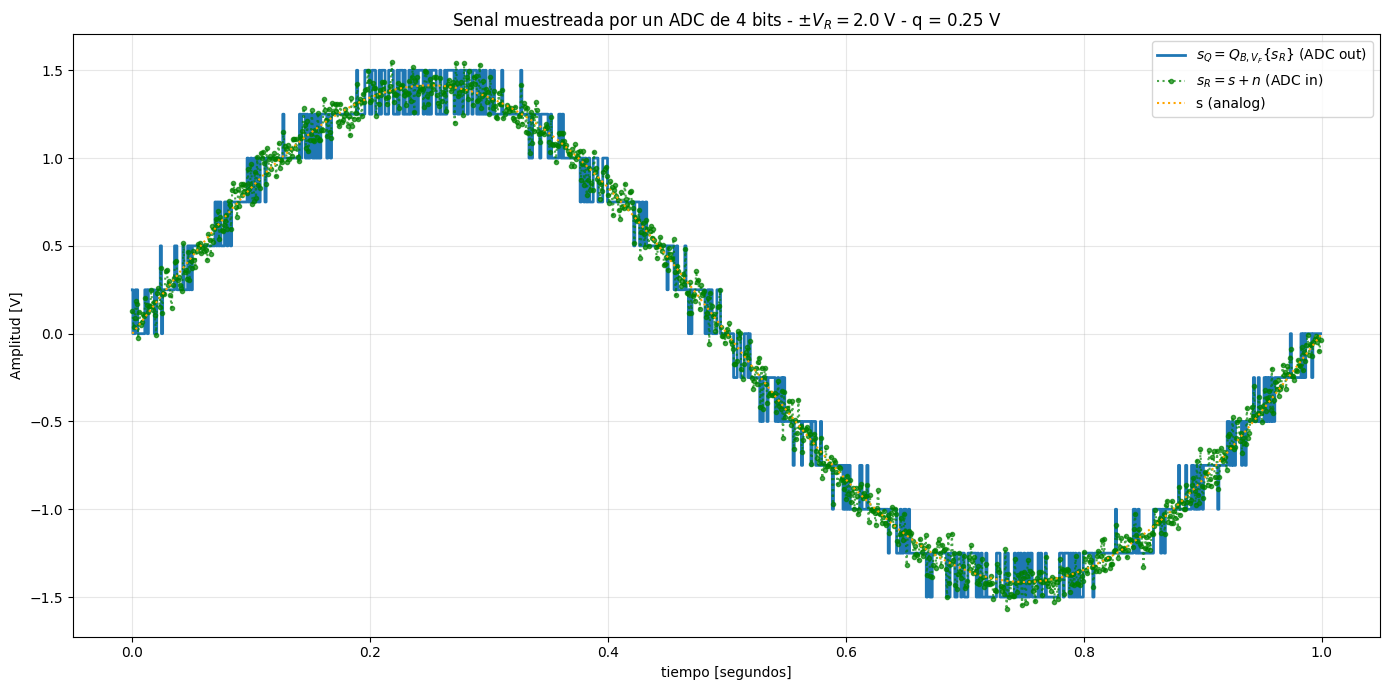

In [2]:
plt.figure(figsize=(14, 7))
plt.step(t, s_Q, where='mid', lw=2, label=r'$s_Q = Q_{B,V_F}\{s_R\}$ (ADC out)')
plt.plot(t, s_R, marker='.', linestyle=':', color='green', markersize=6, alpha=0.7, label=r'$s_R = s + n$ (ADC in)')
plt.plot(t, s, linestyle=':', color='orange', label='s (analog)')
plt.title(f'Senal muestreada por un ADC de {B} bits - $\\pm V_R = {V_F}$ V - q = {q} V')
plt.xlabel('tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

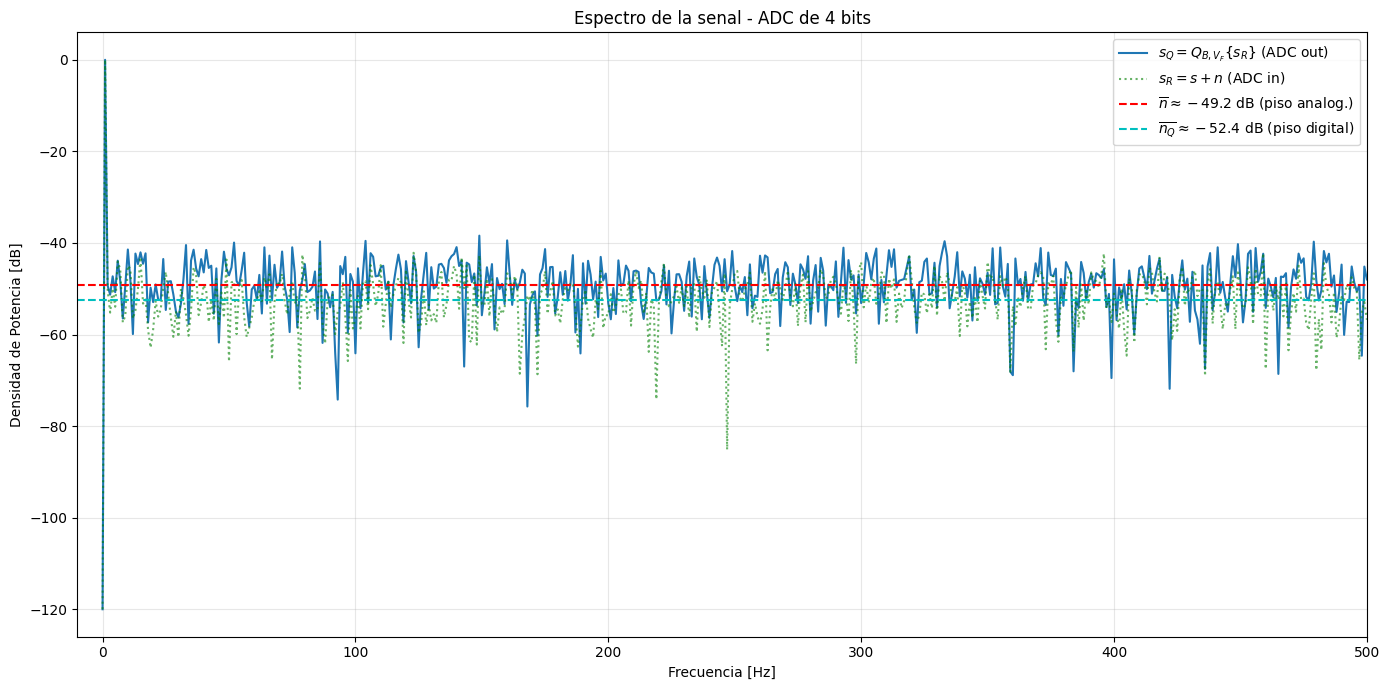

In [3]:
# densidad de pot
f_fft, Pxx_R = sig.periodogram(s_R, fs, window='boxcar', scaling='spectrum')
f_fft, Pxx_Q = sig.periodogram(s_Q, fs, window='boxcar', scaling='spectrum')

# paso a dB
Pxx_R_dB = 10 * np.log10(Pxx_R + 1e-12)
Pxx_Q_dB = 10 * np.log10(Pxx_Q + 1e-12)

# piso analogico => espectro de s_Q
# piso digital => espectro de s_R
piso_analogico_dB = np.mean(Pxx_Q_dB[3:])
piso_digital_dB   = np.mean(Pxx_R_dB[3:])

plt.figure(figsize=(14, 7))
plt.plot(f_fft, Pxx_Q_dB, label=r'$s_Q = Q_{B,V_F}\{s_R\}$ (ADC out)', color='C0')
plt.plot(f_fft, Pxx_R_dB, label=r'$s_R = s + n$ (ADC in)', color='green', alpha=0.6, linestyle=':')
plt.axhline(piso_analogico_dB, color='red', linestyle='--',
            label=f'$\\overline{{n}} \\approx {piso_analogico_dB:.1f}$ dB (piso analog.)')
plt.axhline(piso_digital_dB, color='c', linestyle='--',
            label=f'$\\overline{{n_Q}} \\approx {piso_digital_dB:.1f}$ dB (piso digital)')

plt.title(f'Espectro de la senal - ADC de {B} bits')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de Potencia [dB]')
plt.legend(loc='upper right')
plt.xlim(-10, fs/2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

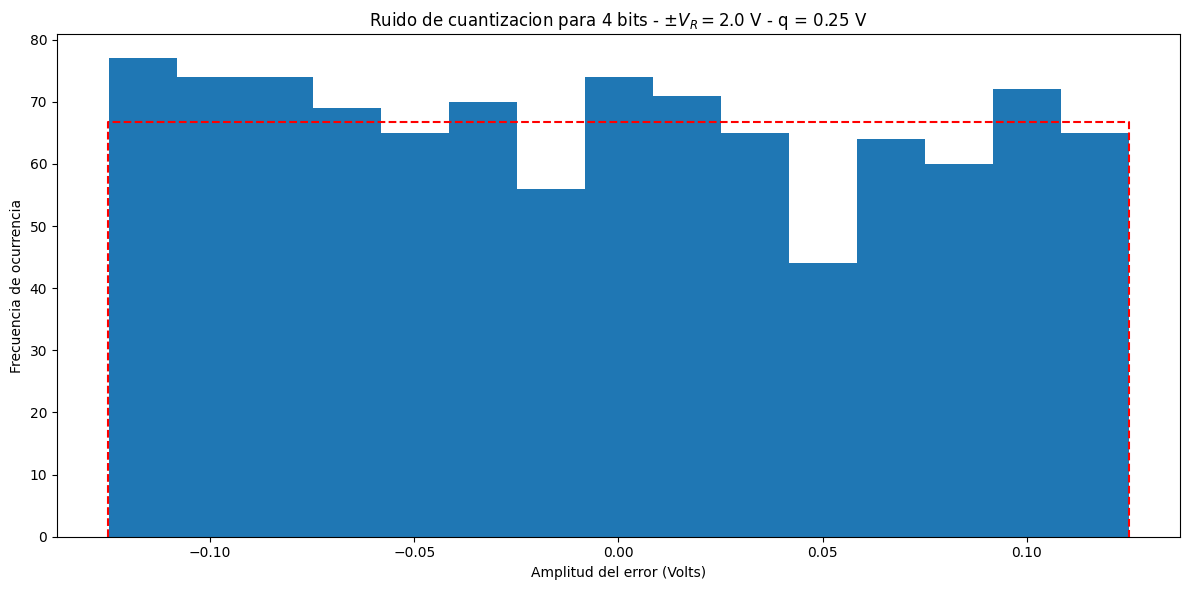

In [4]:
# hitograma del ruido
plt.figure(figsize=(12, 6))
counts, bins, patches = plt.hist(e_q, bins=15, density=False, color='C0')
plt.title(f'Ruido de cuantizacion para {B} bits - $\\pm V_R = {V_F}$ V - q = {q} V')

#  rectángulo teorico ideal (-q/2 y q/2)
altura_teorica = N / 15
plt.plot([-q/2, -q/2, q/2, q/2], [0, altura_teorica, altura_teorica, 0], 'r--', lw=1.5)

plt.xlabel('Amplitud del error (Volts)')
plt.ylabel('Frecuencia de ocurrencia')
plt.tight_layout()
plt.show()

## Punto b)

Se analiza el efecto de variar la resolución del ADC $B \in \{4, 8, 16\}$ bits y la relación entre el ruido analógico y el ruido de cuantización $k_n \in \{1/10,\, 1,\, 10\}$.

Para cada combinación se grafica el espectro de potencia de la salida del ADC y se comparan los pisos de ruido resultantes.

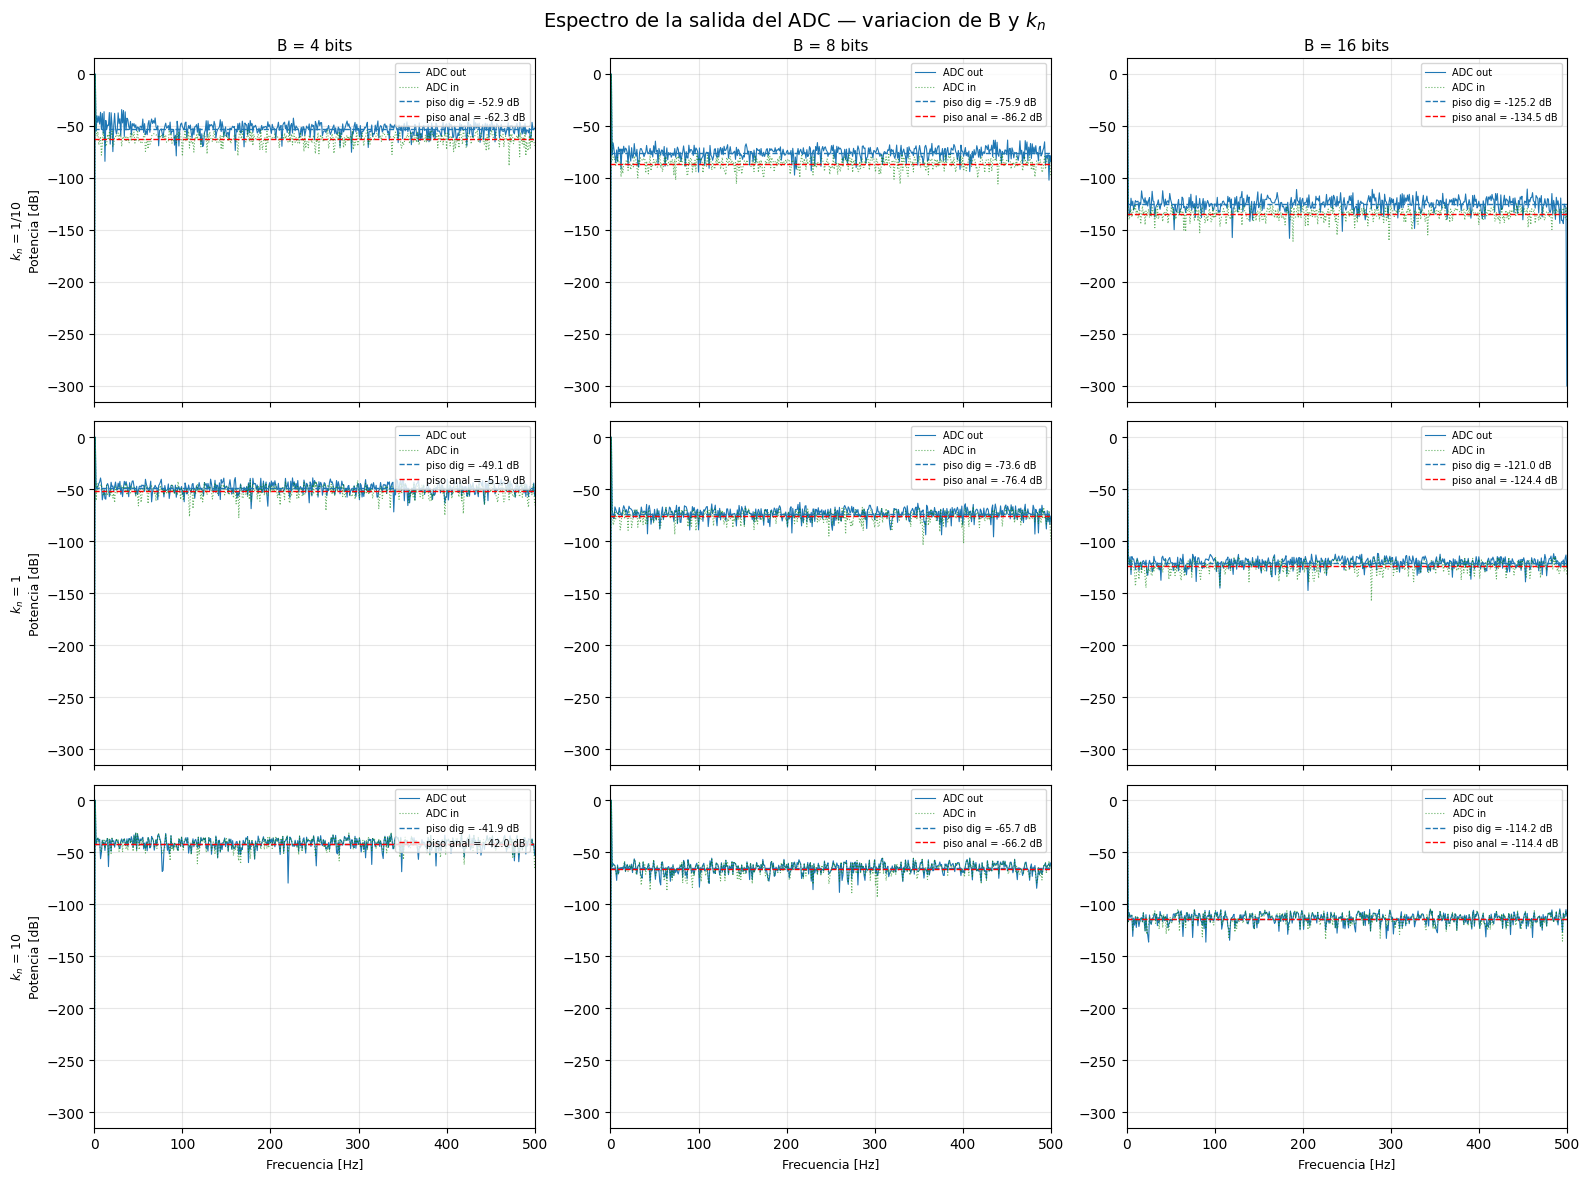

In [5]:
fs   = 1000.0
N    = 1000
f0   = fs / N
V_F  = 2.0
t    = np.arange(N) / fs

B_values  = [4, 8, 16]
kn_values = [1/10, 1, 10]
kn_labels = ['1/10', '1', '10']

np.random.seed(42)   # reproducibilidad

# senal senoidal
s = np.sqrt(2) * np.sin(2 * np.pi * f0 * t)

# unifico graficos
fig, axes = plt.subplots(len(kn_values), len(B_values),
                         figsize=(16, 12), sharex=True, sharey=False)
fig.suptitle('Espectro de la salida del ADC — variacion de B y $k_n$', fontsize=14)

for row, (kn, kn_label) in enumerate(zip(kn_values, kn_labels)):
    for col, B in enumerate(B_values):
        ax = axes[row][col]

        q      = (2 * V_F) / (2**B)
        Pq     = (q**2) / 12
        Pn     = kn * Pq
        sigma_n = np.sqrt(Pn)

        n    = np.random.normal(0, sigma_n, N)
        s_R  = s + n
        s_Q  = np.clip(np.round(s_R / q) * q, -V_F, V_F - q)

        f_fft, Pxx_Q = sig.periodogram(s_Q, fs, window='boxcar', scaling='spectrum')
        f_fft, Pxx_R = sig.periodogram(s_R, fs, window='boxcar', scaling='spectrum')
        Pxx_Q_dB = 10 * np.log10(Pxx_Q + 1e-30)
        Pxx_R_dB = 10 * np.log10(Pxx_R + 1e-30)

        piso_Q = np.mean(Pxx_Q_dB[3:])
        piso_R = np.mean(Pxx_R_dB[3:])

        ax.plot(f_fft, Pxx_Q_dB, color='C0', lw=0.8, label='ADC out')
        ax.plot(f_fft, Pxx_R_dB, color='green', lw=0.8, alpha=0.6,
                linestyle=':', label='ADC in')
        ax.axhline(piso_Q, color='C0',   linestyle='--', lw=1,
                   label=f'piso dig = {piso_Q:.1f} dB')
        ax.axhline(piso_R, color='red',  linestyle='--', lw=1,
                   label=f'piso anal = {piso_R:.1f} dB')

        ax.set_xlim(0, fs/2)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7, loc='upper right')

        if row == 0:
            ax.set_title(f'B = {B} bits', fontsize=11)
        if col == 0:
            ax.set_ylabel(f'$k_n$ = {kn_label}\nPotencia [dB]', fontsize=9)
        if row == len(kn_values) - 1:
            ax.set_xlabel('Frecuencia [Hz]', fontsize=9)

plt.tight_layout()
plt.show()

In [6]:
# tabla de ruidos
print(f"{'B':>4} | {'kn':>6} | {'q [V]':>8} | {'Pq [dBW]':>10} | {'Pn [dBW]':>10} | "
      f"{'piso_Q [dB]':>12} | {'piso_R [dB]':>12} | {'SNR_Q [dB]':>10}")
print("-" * 90)

np.random.seed(42)
P_senal_dB = 10 * np.log10(1.0)  # energia unitaria (0 dB)

for kn, kn_label in zip(kn_values, kn_labels):
    for B in B_values:
        q       = (2 * V_F) / (2**B)
        Pq      = (q**2) / 12
        Pn      = kn * Pq
        sigma_n = np.sqrt(Pn)

        n    = np.random.normal(0, sigma_n, N)
        s_R  = s + n
        s_Q  = np.clip(np.round(s_R / q) * q, -V_F, V_F - q)

        # Piso espectral
        _, Pxx_Q = sig.periodogram(s_Q, fs, window='boxcar', scaling='spectrum')
        _, Pxx_R = sig.periodogram(s_R, fs, window='boxcar', scaling='spectrum')
        piso_Q  = np.mean(10 * np.log10(Pxx_Q[3:] + 1e-30))
        piso_R  = np.mean(10 * np.log10(Pxx_R[3:] + 1e-30))

        # SNR aprox como potencia de senal
        snr_Q = P_senal_dB - piso_Q

        print(f"{B:>4} | {kn_label:>6} | {q:>8.5f} | {10*np.log10(Pq):>10.2f} | "
              f"{10*np.log10(Pn):>10.2f} | {piso_Q:>12.2f} | {piso_R:>12.2f} | {snr_Q:>10.2f}")
    print()

   B |     kn |    q [V] |   Pq [dBW] |   Pn [dBW] |  piso_Q [dB] |  piso_R [dB] | SNR_Q [dB]
------------------------------------------------------------------------------------------
   4 |   1/10 |  0.25000 |     -22.83 |     -32.83 |       -52.87 |       -62.27 |      52.87
   8 |   1/10 |  0.01562 |     -46.92 |     -56.92 |       -75.90 |       -86.19 |      75.90
  16 |   1/10 |  0.00006 |     -95.08 |    -105.08 |      -125.22 |      -134.54 |     125.22

   4 |      1 |  0.25000 |     -22.83 |     -22.83 |       -49.11 |       -51.92 |      49.11
   8 |      1 |  0.01562 |     -46.92 |     -46.92 |       -73.57 |       -76.37 |      73.57
  16 |      1 |  0.00006 |     -95.08 |     -95.08 |      -120.99 |      -124.40 |     120.99

   4 |     10 |  0.25000 |     -22.83 |     -12.83 |       -41.86 |       -41.98 |      41.86
   8 |     10 |  0.01562 |     -46.92 |     -36.92 |       -65.73 |       -66.23 |      65.73
  16 |     10 |  0.00006 |     -95.08 |     -85.08 |      -11

#### Efecto de B

Cada bit adicional reduce el paso de cuantizacion a la mitad: $q = \frac{2V_F}{2^B}$, lo que hace que la potencia de cuantizacion $P_q = q^2/12$ caiga **6 dB por bit**. En el espectro esto se observa como una bajada del piso de ruido digital (~6 dB por cada bit extra). Con B = 16 bits el ruido de cuantizacion es tan pequeno que deja de ser el factor limitante en casi cualquier condicion.

#### Efecto de $k_n$ (rel ruido analogico / cuantizacion)

- **$k_n = 1/10$**: el ruido analogico es mucho menor que el de cuantizacion. El piso espectral del ADC queda dominado por la cuantizacion. Aumentar B mejora significativamente el SNR.
- **$k_n = 1$** (caso del punto a): ruido analogico y de cuantizacion son comparables. El piso digital queda ~3 dB sobre el piso analogico. Este fue el caso estudiado en a).
- **$k_n = 10$**: el ruido analogico domina ampliamente. El piso digital se aproxima al analogico y aumentar B ya no mejora el SNR, porque el cuello de botella es el ruido de entrada, no la cuantizacion.

#### Comparacion con el punto a)

En a) (B = 4, $k_n = 1$) el piso de ruido digital es notoriamente alto debido al paso de cuantizacion grueso ($q = 0.125$ V). Al pasar a B = 8 con el mismo $k_n = 1$ el piso baja ~24 dB, y con B = 16 otros ~48 dB adicionales respecto del caso original. Sin embargo, con $k_n = 10$ todos los valores de B convergen al mismo piso, mostrando que la resolucion del ADC solo importa cuando el ruido analogico no enmascara el error de cuantizacion.

## Relacion entre B bits y SNR


Con $q = 2V_F/2^B$, la potencia de ruido de cuantizacion es:

$$P_q = \frac{q^2}{12} = \frac{V_F^2}{3 \cdot 4^B}$$

El ruido analogico es $P_n = k_n \cdot P_q$, por lo que el ruido total es $(1+k_n)\,P_q$. Para senal de potencia unitaria ($P_s = 1$ W) y $V_F = 2$ V:

$$\text{SNR} = \frac{P_s}{(1+k_n)\,P_q} = \frac{3 \cdot 4^B}{4\,(1+k_n)}$$

$$\boxed{\text{SNR [dB]} \approx 6.02\,B - 1.25 - 10\log_{10}(1+k_n)}$$

La pendiente es siempre ~6 dB por bit. El factor $k_n$ solo desplaza la curva verticalmente (offset), no cambia la pendiente, porque el ruido analogico tambien depende de $B$ a traves de $P_q$.

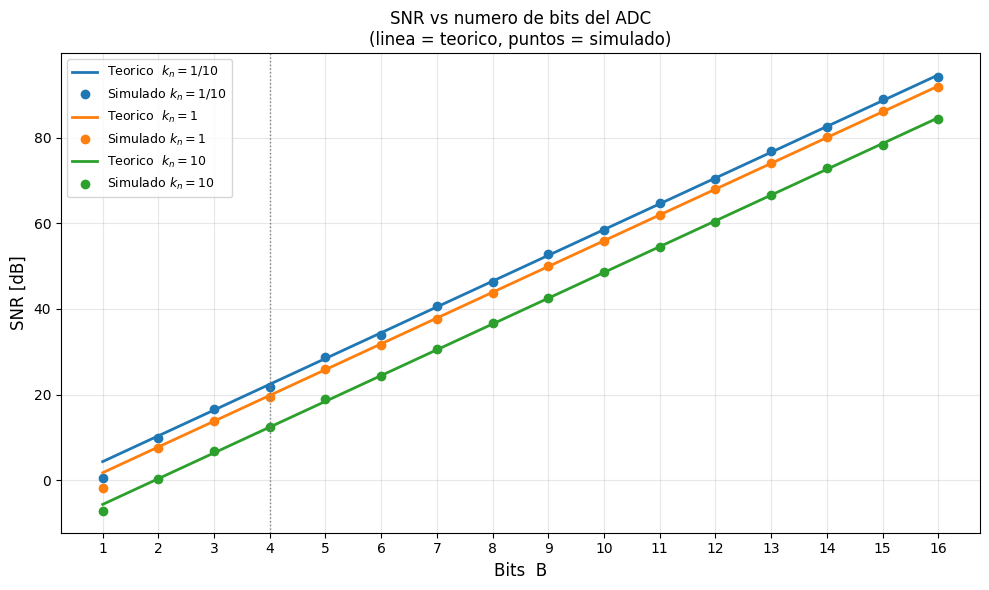

Pendiente empirica SNR vs B (dB/bit):
  kn = 1/10  →  6.12 dB/bit  (teorico: 6.02 dB/bit)
  kn =    1  →  6.11 dB/bit  (teorico: 6.02 dB/bit)
  kn =   10  →  6.04 dB/bit  (teorico: 6.02 dB/bit)


In [ ]:
# params

fs = 1000.0
N  = 1000
f0 = fs / N 
V_F = 2.0
t = np.arange(N) / fs
s = np.sqrt(2) * np.sin(2 * np.pi * f0 * t)

B_range   = np.arange(1, 17) #para ir de  B = 1..16 bits
kn_values = [1/10, 1, 10]
kn_labels = ['1/10', '1', '10']
colors    = ['C0', 'C1', 'C2']

np.random.seed(0)

# SNR empirico

# bin de la fundamental
bin_s = 1

snr_emp = {kn: [] for kn in kn_values}

for B in B_range:
    q       = (2 * V_F) / (2**B)
    Pq      = (q**2) / 12
    for kn in kn_values:
        sigma_n = np.sqrt(kn * Pq)
        n       = np.random.normal(0, sigma_n, N)
        s_Q     = np.clip(np.round((s + n) / q) * q, -V_F, V_F - q)

        _, Pxx = sig.periodogram(s_Q, fs, window='boxcar', scaling='spectrum')
        P_sig   = Pxx[bin_s]
        P_noise = np.sum(Pxx) - P_sig - Pxx[0]
        snr_emp[kn].append(10 * np.log10(P_sig / (P_noise + 1e-30)))

# SNR teorico

B_fine = np.linspace(1, 16, 200)

fig, ax = plt.subplots(figsize=(10, 6))

for kn, label, color in zip(kn_values, kn_labels, colors):
    snr_teo = 6.02 * B_fine - 1.25 - 10 * np.log10(1 + kn)
    ax.plot(B_fine, snr_teo, color=color, lw=2,
            label=f'Teorico  $k_n={label}$')
    ax.plot(B_range, snr_emp[kn], 'o', color=color, markersize=6,
            label=f'Simulado $k_n={label}$')

# para resaltar caso a) =>  B=4, kn=1
ax.axvline(4, color='gray', linestyle=':', lw=1)
ax.set_xlabel('Bits  B', fontsize=12)
ax.set_ylabel('SNR [dB]', fontsize=12)
ax.set_title('SNR vs numero de bits del ADC\n(linea = teorico, puntos = simulado)', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xticks(B_range)
plt.tight_layout()
plt.show()

# verifico pendiente empírica ~6 dB/bit

print("Pendiente empirica SNR vs B (dB/bit):")
for kn, label in zip(kn_values, kn_labels):
    vals = np.array(snr_emp[kn])
    slope = np.polyfit(B_range, vals, 1)[0]
    print(f"  kn = {label:>4}  →  {slope:.2f} dB/bit  (teorico: 6.02 dB/bit)")

## Bonus: SNR de la señal cuantizada

Para cada uno de los 9 casos del punto b) ($B \in \{4, 8, 16\}$ bits, $k_n \in \{1/10,\, 1,\, 10\}$) se calcula la relación señal a ruido de la señal a la salida del ADC.

Se distinguen dos errores:

- **Error de cuantización:** $e_q = s_Q - s_R$, es decir lo que agrega únicamente el cuantizador respecto de lo que entró al ADC.
- **Error total a la salida:** $e = s_Q - s$, que acumula el ruido analógico y el de cuantización, comparando contra la senoidal limpia.

Con eso se definen:

$$\text{SNR}_q = 10\log_{10}\!\left(\frac{P_s}{P_{e_q}}\right) \qquad\qquad \text{SNR}_{tot} = 10\log_{10}\!\left(\frac{P_s}{P_e}\right)$$

siendo $P_s = 1$ W (senoidal de energía normalizada, $A = \sqrt{2}$).

El valor teórico esperado para el SNR total es el deducido antes, ya que los dos ruidos son incorrelados y sus potencias se suman ($P_e = (1 + k_n)P_q$):

$$\text{SNR}_{tot}\,[\text{dB}] \approx 6.02\,B - 1.25 - 10\log_{10}(1 + k_n)$$

Como referencia se agrega el **número de bits efectivo**, que resulta de invertir esa misma expresión:

$$B_{ef} = \frac{\text{SNR}_{tot} + 1.25}{6.02}$$

e indica con cuántos bits *reales* trabaja el ADC una vez que se tiene en cuenta el ruido analógico de entrada.

In [8]:
# SNR de la senal cuantizada para cada caso

fs  = 1000.0
N   = 1000
f0  = fs / N
V_F = 2.0
t   = np.arange(N) / fs

B_values  = [4, 8, 16]
kn_values = [1/10, 1, 10]
kn_labels = ['1/10', '1', '10']

np.random.seed(42)   # mismas realizaciones que en el punto b)

s  = np.sqrt(2) * np.sin(2 * np.pi * f0 * t)
Ps = np.var(s)       # potencia de la senal = 1 W

resultados = []      # guardo todo para la tabla y el grafico

for kn, kn_label in zip(kn_values, kn_labels):
    for B in B_values:
        q       = (2 * V_F) / (2**B)
        Pq      = (q**2) / 12
        sigma_n = np.sqrt(kn * Pq)

        n   = np.random.normal(0, sigma_n, N)
        s_R = s + n
        s_Q = np.clip(np.round(s_R / q) * q, -V_F, V_F - q)

        e_q = s_Q - s_R      # error de cuantizacion
        e   = s_Q - s        # error total a la salida (ruido + cuantizacion)

        snr_q   = 10 * np.log10(Ps / np.var(e_q))
        snr_tot = 10 * np.log10(Ps / np.var(e))
        snr_teo = 6.02 * B - 1.25 - 10 * np.log10(1 + kn)
        B_ef    = (snr_tot + 1.25) / 6.02

        resultados.append(dict(B=B, kn=kn, kn_label=kn_label, q=q, Pq=Pq,
                               snr_q=snr_q, snr_tot=snr_tot,
                               snr_teo=snr_teo, B_ef=B_ef))

# tabla comparativa
print(f"{'B':>3} | {'kn':>5} | {'q [V]':>9} | {'Pq [dBW]':>9} | {'SNR_q [dB]':>11} | "
      f"{'SNR_tot [dB]':>12} | {'SNR_teo [dB]':>12} | {'err [dB]':>9} | {'B_ef':>6}")
print("-" * 105)

kn_previo = None
for r in resultados:
    if kn_previo is not None and r['kn'] != kn_previo:
        print("-" * 105)
    kn_previo = r['kn']
    print(f"{r['B']:>3} | {r['kn_label']:>5} | {r['q']:>9.6f} | {10*np.log10(r['Pq']):>9.2f} | "
          f"{r['snr_q']:>11.2f} | {r['snr_tot']:>12.2f} | {r['snr_teo']:>12.2f} | "
          f"{r['snr_tot'] - r['snr_teo']:>9.2f} | {r['B_ef']:>6.2f}")

  B |    kn |     q [V] |  Pq [dBW] |  SNR_q [dB] | SNR_tot [dB] | SNR_teo [dB] |  err [dB] |   B_ef
---------------------------------------------------------------------------------------------------------
  4 |  1/10 |  0.250000 |    -22.83 |       22.22 |        21.71 |        22.42 |     -0.71 |   3.81
  8 |  1/10 |  0.015625 |    -46.92 |       46.77 |        46.22 |        46.50 |     -0.27 |   7.89
 16 |  1/10 |  0.000061 |    -95.08 |       94.76 |        94.32 |        94.66 |     -0.34 |  15.88
---------------------------------------------------------------------------------------------------------
  4 |     1 |  0.250000 |    -22.83 |       22.70 |        19.53 |        19.82 |     -0.29 |   3.45
  8 |     1 |  0.015625 |    -46.92 |       47.09 |        43.99 |        43.90 |      0.09 |   7.51
 16 |     1 |  0.000061 |    -95.08 |       94.95 |        91.81 |        92.06 |     -0.25 |  15.46
---------------------------------------------------------------------------------

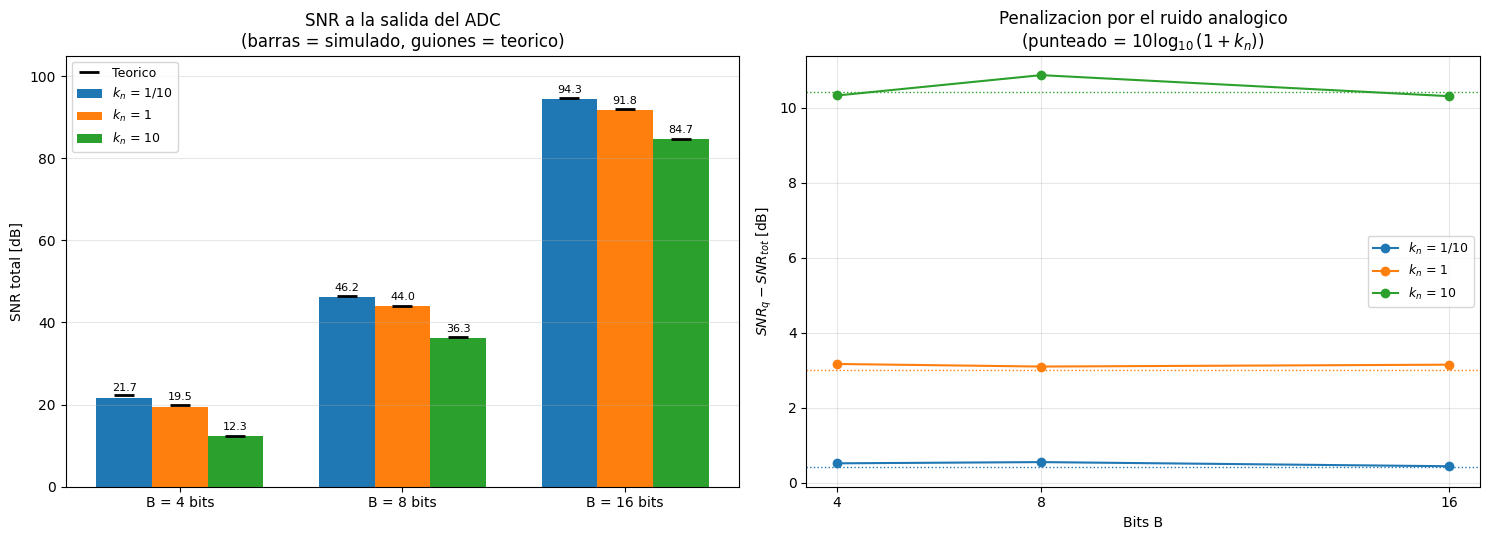

In [9]:
# grafico comparativo del SNR de la senal cuantizada

x      = np.arange(len(B_values))
ancho  = 0.25
colors = ['C0', 'C1', 'C2']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

# barras: SNR total simulado vs teorico
for i, (kn, kn_label) in enumerate(zip(kn_values, kn_labels)):
    fila     = [r for r in resultados if r['kn'] == kn]
    snr_sim  = [r['snr_tot'] for r in fila]
    snr_teo  = [r['snr_teo'] for r in fila]
    pos      = x + (i - 1) * ancho

    ax1.bar(pos, snr_sim, ancho, color=colors[i], label=f'$k_n$ = {kn_label}')
    ax1.plot(pos, snr_teo, 'k_', markersize=14, markeredgewidth=2,
             label='Teorico' if i == 0 else None)
    for p, v in zip(pos, snr_sim):
        ax1.text(p, v + 1.5, f'{v:.1f}', ha='center', fontsize=8)

ax1.set_xticks(x)
ax1.set_xticklabels([f'B = {B} bits' for B in B_values])
ax1.set_ylabel('SNR total [dB]')
ax1.set_title('SNR a la salida del ADC\n(barras = simulado, guiones = teorico)')
ax1.legend(fontsize=9)
ax1.grid(True, axis='y', alpha=0.3)
ax1.set_ylim(0, 105)

# SNR de cuantizacion vs SNR total: cuanto cuesta el ruido analogico
for i, (kn, kn_label) in enumerate(zip(kn_values, kn_labels)):
    fila     = [r for r in resultados if r['kn'] == kn]
    perdida  = [r['snr_q'] - r['snr_tot'] for r in fila]
    ax2.plot(B_values, perdida, 'o-', color=colors[i], label=f'$k_n$ = {kn_label}')
    teorico  = 10 * np.log10(1 + kn)
    ax2.axhline(teorico, color=colors[i], linestyle=':', lw=1)

ax2.set_xticks(B_values)
ax2.set_xlabel('Bits B')
ax2.set_ylabel(r'$SNR_q - SNR_{tot}$ [dB]')
ax2.set_title('Penalizacion por el ruido analogico\n'
              r'(punteado = $10\log_{10}(1+k_n)$)')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Tabla comparativa

| B [bits] | $k_n$ | q [V] | $\text{SNR}_q$ [dB] | $\text{SNR}_{tot}$ [dB] | $\text{SNR}_{teo}$ [dB] | $B_{ef}$ [bits] |
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
| 4  | 1/10 | 0.250000 | 22.22 | 21.71 | 22.42 | 3.81 |
| 8  | 1/10 | 0.015625 | 46.77 | 46.22 | 46.50 | 7.89 |
| 16 | 1/10 | 0.000061 | 94.76 | 94.32 | 94.66 | 15.88 |
| 4  | 1    | 0.250000 | 22.70 | 19.53 | 19.82 | 3.45 |
| 8  | 1    | 0.015625 | 47.09 | 43.99 | 43.90 | 7.51 |
| 16 | 1    | 0.000061 | 94.95 | 91.81 | 92.06 | 15.46 |
| 4  | 10   | 0.250000 | 22.65 | 12.32 | 12.42 | 2.25 |
| 8  | 10   | 0.015625 | 47.14 | 36.26 | 36.50 | 6.23 |
| 16 | 10   | 0.000061 | 95.04 | 84.73 | 84.66 | 14.28 |

### Conclusiones

El $\text{SNR}_q$ solo depende de B. Para un mismo B, las tres filas dan prácticamente el mismo valor (≈22.5 dB con 4 bits, ≈47 dB con 8 bits, ≈95 dB con 16 bits), independientemente de $k_n$. Coincide con $\text{SNR}_q = 6.02B - 1.25$ dB (22.83 / 46.91 / 95.07 dB), porque el cuantizador siempre agrega la misma potencia $P_q = q^2/12$ sin importar cuánto ruido traiga la señal de entrada.

El $\text{SNR}_{tot}$ es el que paga el ruido analógico. La diferencia $\text{SNR}_q - \text{SNR}_{tot}$ vale exactamente $10\log_{10}(1+k_n)$: 0.4 dB para $k_n = 1/10$, 3 dB para $k_n = 1$ y 10.4 dB para $k_n = 10$. Se ve en la tabla comparando columnas y en el panel derecho del gráfico, donde los puntos simulados caen sobre las líneas punteadas teóricas.

Regla de los 6 dB por bit. Dentro de cada bloque de $k_n$, pasar de 4 a 8 bits mejora el SNR unos 24 dB (4 bits × 6.02) y de 8 a 16 bits unos 48 dB más. El $k_n$ desplaza toda la columna hacia abajo pero no cambia la pendiente: es un offset, no una pérdida de resolución por bit.

Bits efectivos. Con $k_n = 1/10$ el ADC entrega casi toda su resolución nominal ($B_{ef} \approx B - 0.15$). Con $k_n = 1$ se pierde medio bit y con $k_n = 10$ se pierden entre 1.7 y 1.8 bits: un ADC de 16 bits con esa cantidad de ruido en la entrada rinde como uno de ~14 bits. Es decir que no tiene sentido pagar más resolución si la cadena analógica previa al ADC no acompaña.

Ajuste con la teoría. Todos los valores simulados quedan dentro de ±0.7 dB del modelo $6.02B - 1.25 - 10\log_{10}(1+k_n)$. Las diferencias que quedan se explican porque con N = 1000 muestras las potencias se estiman sobre una única realización del ruido, y porque con B = 4 el error de cuantización no es del todo incorrelado con la señal (el modelo de ruido uniforme es una aproximación que mejora al aumentar B).